In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/robiulhasanjisan/smart-healthcare-and-lifestyle-prediction-dataset/smart_healthcare_dataset.csv


In [2]:
# ===================================== LIBRARIES =============================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time, tracemalloc, warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

sns.set_style('whitegrid')
RANDOM_STATE = 42

# Load dataset (Kaggle path)
df = pd.read_csv('/kaggle/input/datasets/robiulhasanjisan/smart-healthcare-and-lifestyle-prediction-dataset/smart_healthcare_dataset.csv')
print('Shape:', df.shape)
df.head()

Shape: (5000, 16)


,age,gender,bmi,exercise_level,smoking,alcohol,blood_pressure,cholesterol,glucose,fatigue,chest_pain,dizziness,heart_disease,diabetes,stroke,health_risk_score
0,56,Male,22.6,2,1,1,169,225,74,0,1,0,0,0,0,100.0
1,69,Female,28.2,0,1,1,136,230,198,0,1,0,1,1,1,100.0
2,46,Female,25.1,1,0,1,142,221,89,0,1,1,0,0,0,100.0
3,32,Female,18.0,0,0,1,173,296,152,1,0,0,0,0,0,100.0
4,60,Female,20.1,2,1,0,130,292,133,1,1,1,0,1,0,100.0


In [3]:
# ================================= FINDING THE CORRECT PATH OF FILES ( DATASET ) ===========================================
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/robiulhasanjisan/smart-healthcare-and-lifestyle-prediction-dataset/smart_healthcare_dataset.csv


In [4]:
# ======================= PREPROCESSING THE DATASET ==========================================
df.info()
print('\nMissing values:\n', df.isnull().sum())
print('\nTarget distribution (heart_disease):\n', df['heart_disease'].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   age                5000 non-null   int64  
 1   gender             5000 non-null   object 
 2   bmi                5000 non-null   float64
 3   exercise_level     5000 non-null   int64  
 4   smoking            5000 non-null   int64  
 5   alcohol            5000 non-null   int64  
 6   blood_pressure     5000 non-null   int64  
 7   cholesterol        5000 non-null   int64  
 8   glucose            5000 non-null   int64  
 9   fatigue            5000 non-null   int64  
 10  chest_pain         5000 non-null   int64  
 11  dizziness          5000 non-null   int64  
 12  heart_disease      5000 non-null   int64  
 13  diabetes           5000 non-null   int64  
 14  stroke             5000 non-null   int64  
 15  health_risk_score  5000 non-null   float64
dtypes: float64(2), int64(13)

1


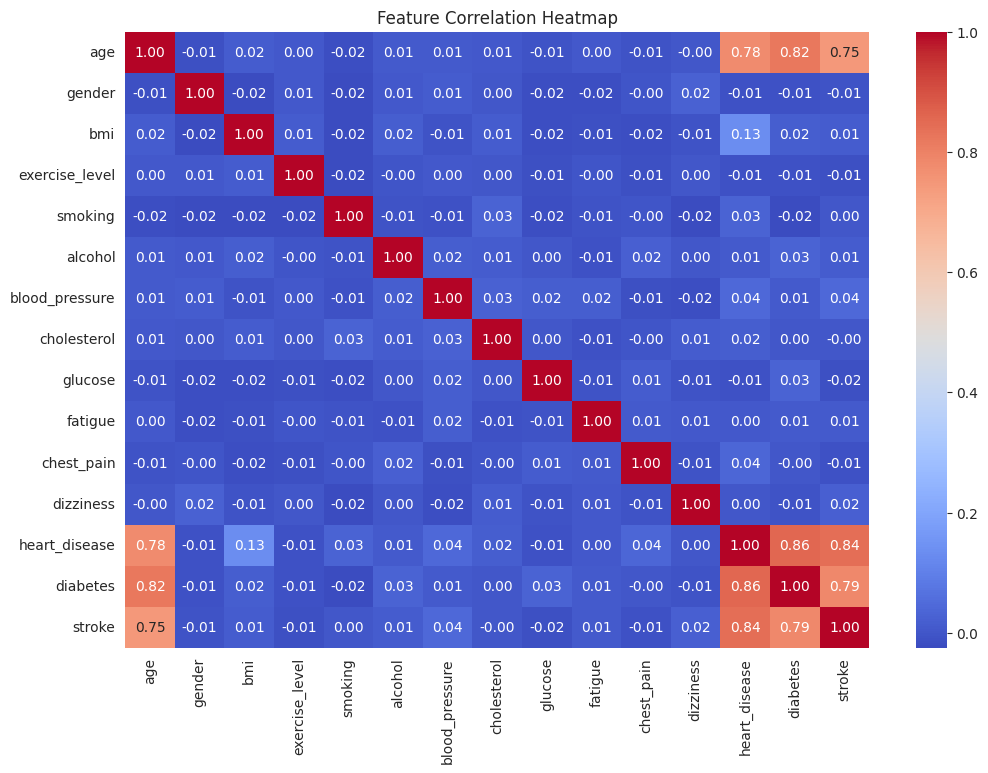

In [5]:
# health_risk_score is constant (==100.0) for all rows -> not useful at all dropping it
print(df['health_risk_score'].nunique())
df = df.drop(columns=['health_risk_score'])

# Correlation heatmap (numeric features)
plt.figure(figsize=(12,8))
numeric_df = df.copy()
numeric_df['gender'] = LabelEncoder().fit_transform(numeric_df['gender'])
sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()

In [6]:
# Encoding categorical column for male and female for better accuracy
df_enc = df.copy()
df_enc['gender'] = LabelEncoder().fit_transform(df_enc['gender'])  # Male/Female: 0/1

X = df_enc.drop(columns=['heart_disease'])
y = df_enc['heart_disease']

print('Feature columns:', X.columns.tolist())
print('X shape:', X.shape, '| y shape:', y.shape)

# Train/test split (held out for final, unbiased evaluation)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

# Standardize
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('Total features available for PCA:', X_train_scaled.shape[1])

Feature columns: ['age', 'gender', 'bmi', 'exercise_level', 'smoking', 'alcohol', 'blood_pressure', 'cholesterol', 'glucose', 'fatigue', 'chest_pain', 'dizziness', 'diabetes', 'stroke']
X shape: (5000, 14) | y shape: (5000,)
Total features available for PCA: 14


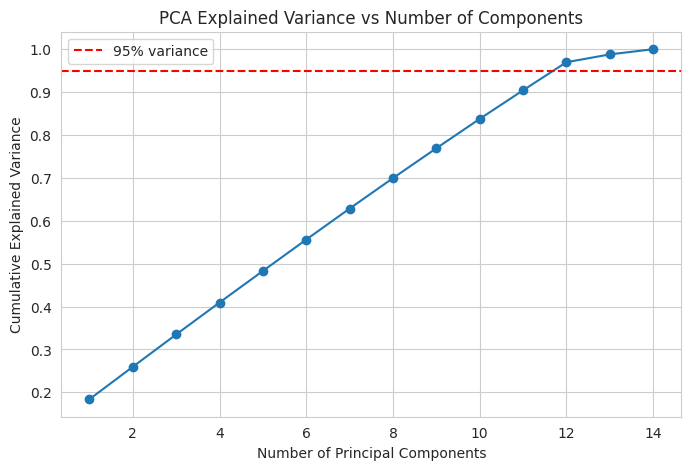

Explained variance ratio per component:
  PC1: cumulative = 0.184
  PC2: cumulative = 0.260
  PC3: cumulative = 0.335
  PC4: cumulative = 0.409
  PC5: cumulative = 0.483
  PC6: cumulative = 0.556
  PC7: cumulative = 0.628
  PC8: cumulative = 0.699
  PC9: cumulative = 0.769
  PC10: cumulative = 0.838
  PC11: cumulative = 0.904
  PC12: cumulative = 0.970
  PC13: cumulative = 0.988
  PC14: cumulative = 1.000


In [7]:
# PCA explained variance (to understand how many components are 'meaningful')
pca_full = PCA(random_state=RANDOM_STATE).fit(X_train_scaled)
explained = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(8,5))
plt.plot(range(1, len(explained)+1), explained, marker='o')
plt.axhline(0.95, color='r', linestyle='--', label='95% variance')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Explained Variance vs Number of Components')
plt.legend()
plt.show()

print('Explained variance ratio per component:')
for i, v in enumerate(explained, 1):
    print(f'  PC{i}: cumulative = {v:.3f}')

In [8]:
# ABLATION ANALYSIS: vary number of retained PCA components
# Using a fixed baseline model (Random Forest) to measure downstream impact
n_features = X_train_scaled.shape[1]
component_options = list(range(2, n_features+1, 2)) + [n_features]
component_options = sorted(set(component_options))

ablation_results = []

for n_comp in component_options:
    pca = PCA(n_components=n_comp, random_state=RANDOM_STATE)
    X_train_pca = pca.fit_transform(X_train_scaled)
    X_test_pca = pca.transform(X_test_scaled)

    model = RandomForestClassifier(random_state=RANDOM_STATE)

    start_train = time.perf_counter()
    model.fit(X_train_pca, y_train)
    train_time = time.perf_counter() - start_train

    start_pred = time.perf_counter()
    y_pred = model.predict(X_test_pca)
    pred_time = time.perf_counter() - start_pred

    acc = accuracy_score(y_test, y_pred)

    ablation_results.append({
        'n_components': n_comp,
        'explained_variance': pca.explained_variance_ratio_.sum(),
        'accuracy': acc,
        'train_time_s': train_time,
        'pred_latency_s': pred_time
    })

ablation_df = pd.DataFrame(ablation_results)
ablation_df

,n_components,explained_variance,accuracy,train_time_s,pred_latency_s
0,2,0.259560,0.936,0.488248,0.012829
1,4,0.409422,0.952,0.751945,0.012336
2,6,0.556155,0.946,0.850426,0.013400
3,8,0.699431,0.948,0.951301,0.013798
4,10,0.837520,0.959,1.223933,0.012924
5,12,0.969689,0.965,1.191443,0.013801
6,14,1.000000,0.966,1.064720,0.013076


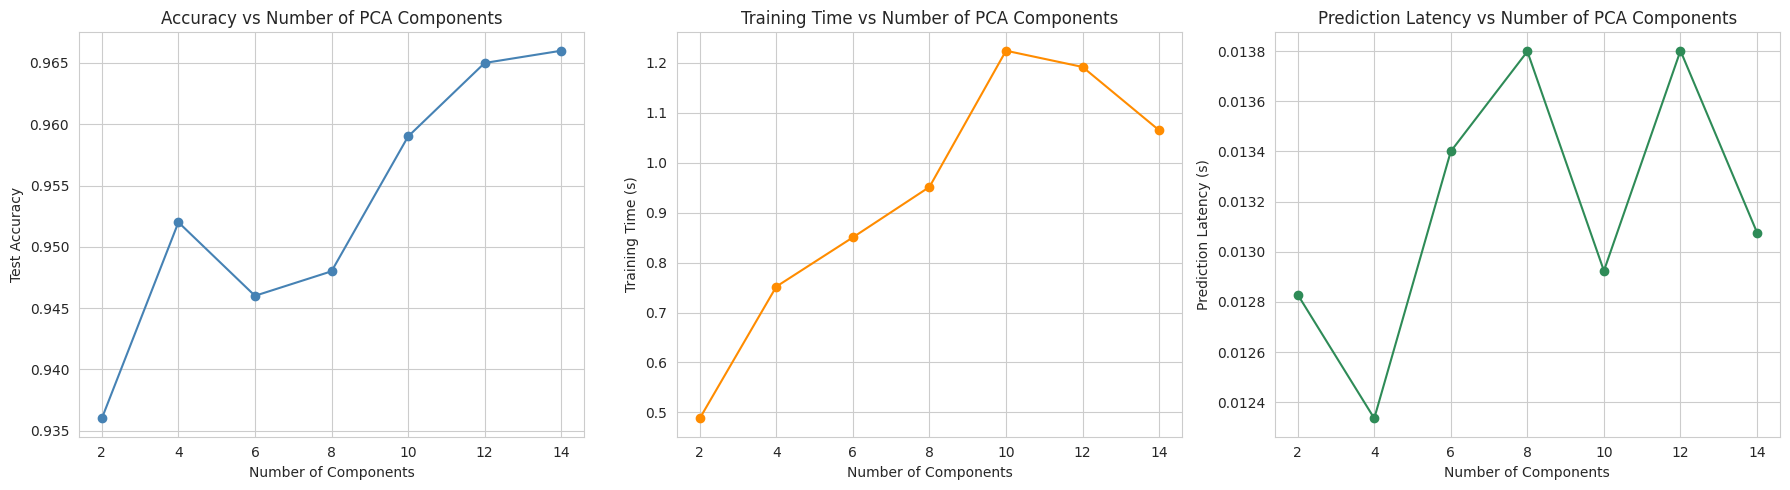

In [9]:
# Visualizing ablation trade-offs
fig, axes = plt.subplots(1, 3, figsize=(18,5))

axes[0].plot(ablation_df['n_components'], ablation_df['accuracy'], marker='o', color='steelblue')
axes[0].set_title('Accuracy vs Number of PCA Components')
axes[0].set_xlabel('Number of Components')
axes[0].set_ylabel('Test Accuracy')

axes[1].plot(ablation_df['n_components'], ablation_df['train_time_s'], marker='o', color='darkorange')
axes[1].set_title('Training Time vs Number of PCA Components')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Training Time (s)')

axes[2].plot(ablation_df['n_components'], ablation_df['pred_latency_s'], marker='o', color='seagreen')
axes[2].set_title('Prediction Latency vs Number of PCA Components')
axes[2].set_xlabel('Number of Components')
axes[2].set_ylabel('Prediction Latency (s)')

plt.tight_layout()
plt.show()

In [10]:
# Based on the ablation curve, picking a chosen number of PCA components that retains
# most variance while keeping dimensionality reduced. We choose the smallest n_components
# that explains >= 95% variance.
N_COMPONENTS = int(ablation_df[ablation_df['explained_variance'] >= 0.95]['n_components'].min())
if np.isnan(N_COMPONENTS):
    N_COMPONENTS = n_features  # fallback: use all features

print(f'Selected number of PCA components: {N_COMPONENTS}')

pca_final = PCA(n_components=N_COMPONENTS, random_state=RANDOM_STATE)
X_train_pca = pca_final.fit_transform(X_train_scaled)
X_test_pca = pca_final.transform(X_test_scaled)

print('Reduced training shape:', X_train_pca.shape)
print('Total explained variance:', pca_final.explained_variance_ratio_.sum())

Selected number of PCA components: 12
Reduced training shape: (4000, 12)
Total explained variance: 0.9696888561184687


In [11]:
# Applying classifiers for getting identifying which classifier performs the best ( KNN, NAIVE BAYES, SVM, DECISION TREE, RANDOM FOREST)
baseline_models = {
    'KNN': KNeighborsClassifier(),
    'Naive Bayes': GaussianNB(),
    'SVM': SVC(random_state=RANDOM_STATE),
    'Decision Tree': DecisionTreeClassifier(random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(random_state=RANDOM_STATE)
}

baseline_results = []

for name, model in baseline_models.items():
    start = time.perf_counter()
    model.fit(X_train_pca, y_train)
    train_time = time.perf_counter() - start

    y_pred = model.predict(X_test_pca)
    acc = accuracy_score(y_test, y_pred)

    baseline_results.append({'model': name, 'baseline_accuracy': acc, 'train_time_s': train_time})
    print(f'--- {name} ---')
    print(classification_report(y_test, y_pred, target_names=['No Disease','Disease']))

baseline_df = pd.DataFrame(baseline_results)
baseline_df

--- KNN ---
              precision    recall  f1-score   support

  No Disease       0.95      0.97      0.96       700
     Disease       0.93      0.89      0.91       300

    accuracy                           0.95      1000
   macro avg       0.94      0.93      0.94      1000
weighted avg       0.95      0.95      0.95      1000

--- Naive Bayes ---
              precision    recall  f1-score   support

  No Disease       0.98      0.94      0.96       700
     Disease       0.87      0.96      0.91       300

    accuracy                           0.94      1000
   macro avg       0.92      0.95      0.94      1000
weighted avg       0.95      0.94      0.94      1000

--- SVM ---
              precision    recall  f1-score   support

  No Disease       0.97      0.98      0.98       700
     Disease       0.96      0.93      0.94       300

    accuracy                           0.97      1000
   macro avg       0.96      0.96      0.96      1000
weighted avg       0.97      0

,model,baseline_accuracy,train_time_s
0,KNN,0.947,0.010119
1,Naive Bayes,0.944,0.002293
2,SVM,0.967,0.079528
3,Decision Tree,0.955,0.041434
4,Random Forest,0.965,1.188941


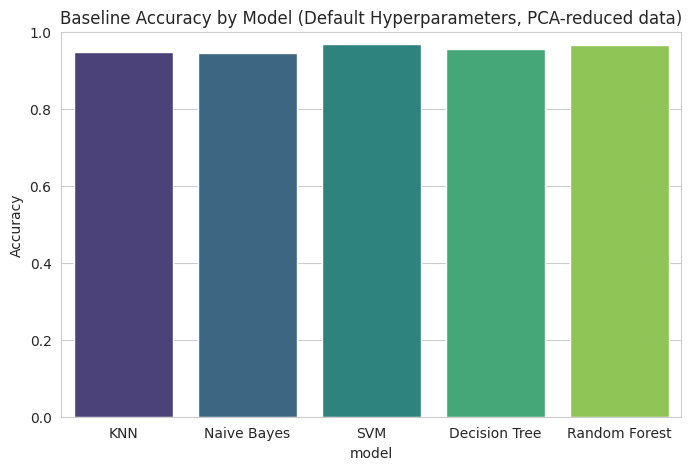

In [12]:
#plotting  ALL 5 classifiers into barcharts for visulization
plt.figure(figsize=(8,5))
sns.barplot(data=baseline_df, x='model', y='baseline_accuracy', palette='viridis')
plt.title('Baseline Accuracy by Model (Default Hyperparameters, PCA-reduced data)')
plt.ylabel('Accuracy')
plt.ylim(0,1)
plt.show()

In [13]:
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Using full training data (PCA-reduced) for CV
cv_results = []
for name, model in baseline_models.items():
    scores = cross_val_score(model, X_train_pca, y_train, cv=kf, scoring='accuracy')
    cv_results.append({
        'model': name,
        'cv_mean_accuracy': scores.mean(),
        'cv_std_accuracy': scores.std()
    })
    print(f'{name}: fold scores = {np.round(scores,4)} | mean = {scores.mean():.4f} | std = {scores.std():.4f}')

cv_df = pd.DataFrame(cv_results)
cv_df

KNN: fold scores = [0.9575 0.965  0.9575 0.9488 0.9588] | mean = 0.9575 | std = 0.0052
Naive Bayes: fold scores = [0.945  0.94   0.9362 0.9525 0.9525] | mean = 0.9453 | std = 0.0065
SVM: fold scores = [0.965  0.98   0.9775 0.9688 0.9688] | mean = 0.9720 | std = 0.0057
Decision Tree: fold scores = [0.9675 0.9675 0.955  0.9612 0.955 ] | mean = 0.9613 | std = 0.0056
Random Forest: fold scores = [0.975  0.9812 0.9788 0.965  0.97  ] | mean = 0.9740 | std = 0.0059


,model,cv_mean_accuracy,cv_std_accuracy
0,KNN,0.95750,0.005184
1,Naive Bayes,0.94525,0.006538
2,SVM,0.97200,0.005734
3,Decision Tree,0.96125,0.005590
4,Random Forest,0.97400,0.005884


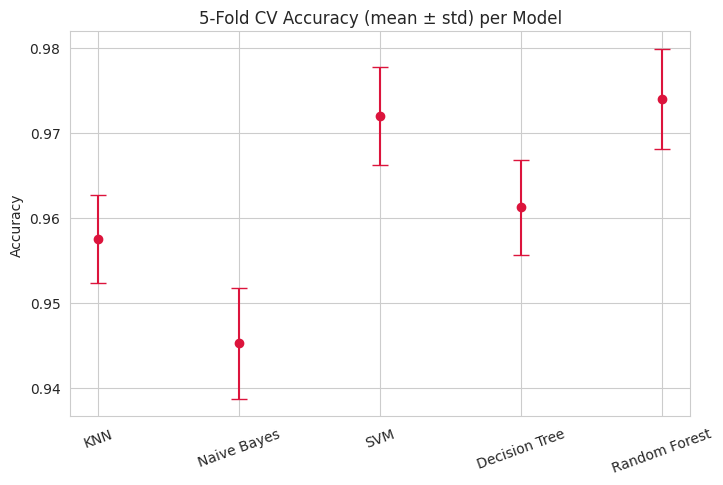

In [14]:
plt.figure(figsize=(8,5))
plt.errorbar(cv_df['model'], cv_df['cv_mean_accuracy'], yerr=cv_df['cv_std_accuracy'],
             fmt='o', capsize=6, color='crimson')
plt.title('5-Fold CV Accuracy (mean ± std) per Model')
plt.ylabel('Accuracy')
plt.xticks(rotation=20)
plt.show()

In [15]:
tuning_results = []
best_models = {}

# KNN: Grid Search
knn_grid = {'n_neighbors': [3,5,7,9,11,15], 'weights': ['uniform','distance']}
knn_search = GridSearchCV(KNeighborsClassifier(), knn_grid, cv=kf, scoring='accuracy', n_jobs=-1)
knn_search.fit(X_train_pca, y_train)
best_models['KNN'] = knn_search.best_estimator_
print('KNN best params:', knn_search.best_params_, '| best CV acc:', knn_search.best_score_)

# SVM: Random Search 
svm_dist = {'C': [0.1,1,10,100], 'kernel': ['rbf','linear','poly'], 'gamma': ['scale','auto']}
svm_search = RandomizedSearchCV(SVC(random_state=RANDOM_STATE), svm_dist, n_iter=10,
                                  cv=kf, scoring='accuracy', random_state=RANDOM_STATE, n_jobs=-1)
svm_search.fit(X_train_pca, y_train)
best_models['SVM'] = svm_search.best_estimator_
print('SVM best params:', svm_search.best_params_, '| best CV acc:', svm_search.best_score_)

# Decision Tree: Grid Search 
dt_grid = {'max_depth': [3,5,7,10,None], 'min_samples_split': [2,5,10]}
dt_search = GridSearchCV(DecisionTreeClassifier(random_state=RANDOM_STATE), dt_grid,
                          cv=kf, scoring='accuracy', n_jobs=-1)
dt_search.fit(X_train_pca, y_train)
best_models['Decision Tree'] = dt_search.best_estimator_
print('Decision Tree best params:', dt_search.best_params_, '| best CV acc:', dt_search.best_score_)

# Random Forest: Random Search 
rf_dist = {'n_estimators': [50,100,150,200], 'max_depth': [5,10,15,None]}
rf_search = RandomizedSearchCV(RandomForestClassifier(random_state=RANDOM_STATE), rf_dist, n_iter=8,
                                 cv=kf, scoring='accuracy', random_state=RANDOM_STATE, n_jobs=-1)
rf_search.fit(X_train_pca, y_train)
best_models['Random Forest'] = rf_search.best_estimator_
print('Random Forest best params:', rf_search.best_params_, '| best CV acc:', rf_search.best_score_)

# Naive Bayes (no tuning)
best_models['Naive Bayes'] = GaussianNB().fit(X_train_pca, y_train)

KNN best params: {'n_neighbors': 7, 'weights': 'distance'} | best CV acc: 0.9600000000000002
SVM best params: {'kernel': 'linear', 'gamma': 'scale', 'C': 0.1} | best CV acc: 0.97475
Decision Tree best params: {'max_depth': 10, 'min_samples_split': 2} | best CV acc: 0.96175
Random Forest best params: {'n_estimators': 150, 'max_depth': None} | best CV acc: 0.97475


In [16]:
# Evaluating tuned models on the held-out test set
for name, model in best_models.items():
    y_pred = model.predict(X_test_pca)
    acc = accuracy_score(y_test, y_pred)
    tuning_results.append({'model': name, 'tuned_test_accuracy': acc})

tuned_df = pd.DataFrame(tuning_results)
tuned_df

,model,tuned_test_accuracy
0,KNN,0.944
1,SVM,0.971
2,Decision Tree,0.949
3,Random Forest,0.962
4,Naive Bayes,0.944


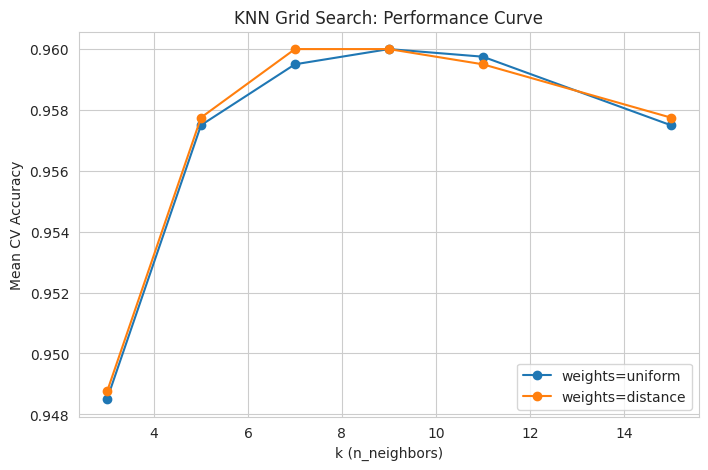

In [17]:
# Ploting Grid Search convergence for KNN (k vs CV accuracy) as a 'performance curve'
results_df_knn = pd.DataFrame(knn_search.cv_results_)
plt.figure(figsize=(8,5))
for w in ['uniform','distance']:
    subset = results_df_knn[results_df_knn['param_weights']==w]
    plt.plot(subset['param_n_neighbors'], subset['mean_test_score'], marker='o', label=f'weights={w}')
plt.xlabel('k (n_neighbors)')
plt.ylabel('Mean CV Accuracy')
plt.title('KNN Grid Search: Performance Curve')
plt.legend()
plt.show()

In [18]:
nf_results = []
rf_params = rf_search.best_params_

for n_comp in component_options:
    pca = PCA(n_components=n_comp, random_state=RANDOM_STATE)
    Xtr = pca.fit_transform(X_train_scaled)
    Xte = pca.transform(X_test_scaled)

    model = RandomForestClassifier(random_state=RANDOM_STATE, **rf_params)

    tracemalloc.start()
    start = time.perf_counter()
    model.fit(Xtr, y_train)
    elapsed = time.perf_counter() - start
    current, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()

    cv_scores = cross_val_score(model, Xtr, y_train, cv=kf, scoring='accuracy')

    nf_results.append({
        'n_components': n_comp,
        'train_time_s': elapsed,
        'peak_memory_kb': peak / 1024,
        'cv_mean_accuracy': cv_scores.mean(),
        'cv_std_accuracy': cv_scores.std()
    })

nf_df = pd.DataFrame(nf_results)
nf_df

,n_components,train_time_s,peak_memory_kb,cv_mean_accuracy,cv_std_accuracy
0,2,2.352236,571.945312,0.94150,0.006442
1,4,2.754866,595.586914,0.95025,0.006344
2,6,2.901880,625.392578,0.95475,0.004569
3,8,3.155478,657.090820,0.95200,0.004153
4,10,3.505337,688.390625,0.96100,0.004962
5,12,3.473098,719.391602,0.97475,0.006393
6,14,3.247814,750.641602,0.97450,0.002806


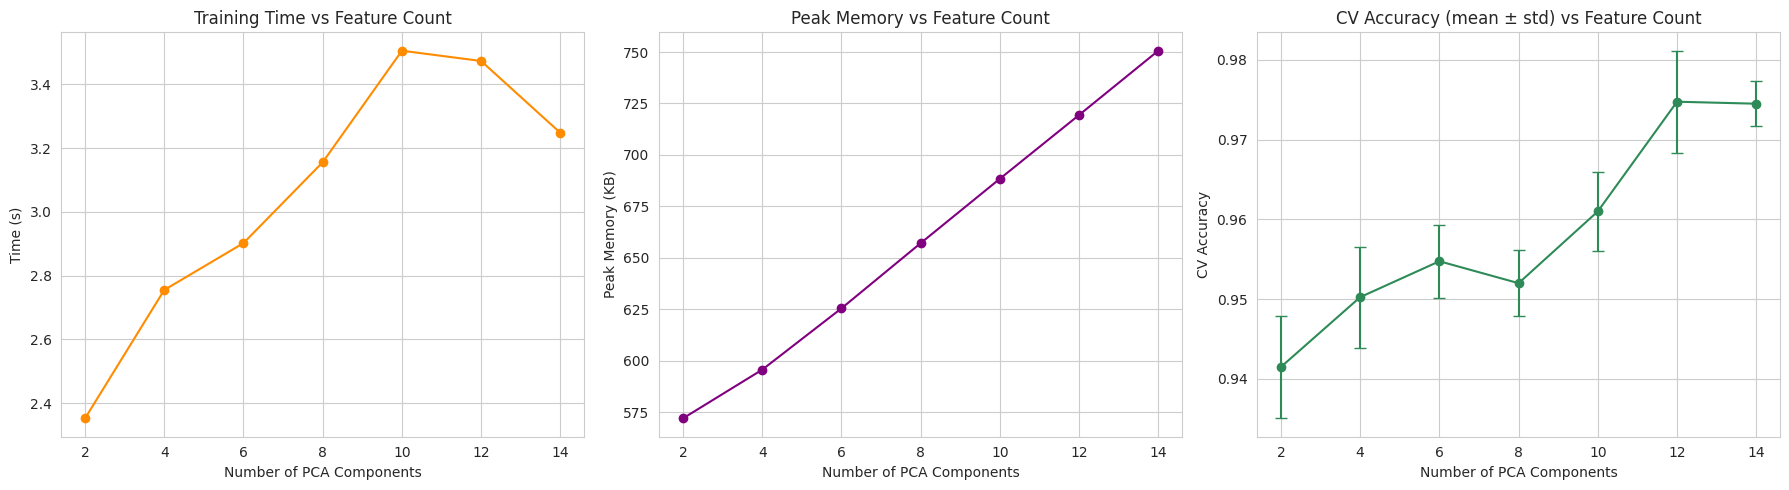

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(18,5))
axes[0].plot(nf_df['n_components'], nf_df['train_time_s'], marker='o', color='darkorange')
axes[0].set_title('Training Time vs Feature Count')
axes[0].set_xlabel('Number of PCA Components')
axes[0].set_ylabel('Time (s)')

axes[1].plot(nf_df['n_components'], nf_df['peak_memory_kb'], marker='o', color='purple')
axes[1].set_title('Peak Memory vs Feature Count')
axes[1].set_xlabel('Number of PCA Components')
axes[1].set_ylabel('Peak Memory (KB)')

axes[2].errorbar(nf_df['n_components'], nf_df['cv_mean_accuracy'], yerr=nf_df['cv_std_accuracy'],
                  fmt='o-', capsize=4, color='seagreen')
axes[2].set_title('CV Accuracy (mean ± std) vs Feature Count')
axes[2].set_xlabel('Number of PCA Components')
axes[2].set_ylabel('CV Accuracy')

plt.tight_layout()
plt.show()

In [20]:
# Test 1: CV stability across two different random shuffles
kf_a = KFold(n_splits=5, shuffle=True, random_state=1)
kf_b = KFold(n_splits=5, shuffle=True, random_state=2)

model_for_test = RandomForestClassifier(random_state=RANDOM_STATE, **rf_params)
scores_a = cross_val_score(model_for_test, X_train_pca, y_train, cv=kf_a, scoring='accuracy')
scores_b = cross_val_score(model_for_test, X_train_pca, y_train, cv=kf_b, scoring='accuracy')

print('Run A: mean =', scores_a.mean().round(4), ' std =', scores_a.std().round(4))
print('Run B: mean =', scores_b.mean().round(4), ' std =', scores_b.std().round(4))

diff = abs(scores_a.mean() - scores_b.mean())
print(f'Difference in mean CV accuracy between two shuffles: {diff:.4f}')
assert diff < 0.03, 'CV results are not stable across shuffles!'
print('PASS: CV results are stable (difference < 0.03) across different random shuffles.')

Run A: mean = 0.972  std = 0.0013
Run B: mean = 0.9727  std = 0.0076
Difference in mean CV accuracy between two shuffles: 0.0007
PASS: CV results are stable (difference < 0.03) across different random shuffles.


In [21]:
# Test 2: Hyperparameter search improves (or matches) the default baseline CV score
default_rf = RandomForestClassifier(random_state=RANDOM_STATE)
default_cv = cross_val_score(default_rf, X_train_pca, y_train, cv=kf, scoring='accuracy').mean()
tuned_cv = rf_search.best_score_

print(f'Default RF CV accuracy: {default_cv:.4f}')
print(f'Tuned RF CV accuracy (from search): {tuned_cv:.4f}')

assert tuned_cv >= default_cv - 1e-6, 'Tuned model did not match/exceed default performance!'
print('PASS: Hyperparameter search converged to a result at least as good as the default configuration.')

Default RF CV accuracy: 0.9740
Tuned RF CV accuracy (from search): 0.9748
PASS: Hyperparameter search converged to a result at least as good as the default configuration.


In [22]:
# Combine baseline, CV, and tuned results into a single results matrix
results_matrix = baseline_df.merge(cv_df, on='model').merge(tuned_df, on='model')
results_matrix['improvement_vs_baseline'] = results_matrix['tuned_test_accuracy'] - results_matrix['baseline_accuracy']
results_matrix = results_matrix[['model','baseline_accuracy','cv_mean_accuracy','cv_std_accuracy',
                                    'tuned_test_accuracy','improvement_vs_baseline']]
results_matrix

,model,baseline_accuracy,cv_mean_accuracy,cv_std_accuracy,tuned_test_accuracy,improvement_vs_baseline
0,KNN,0.947,0.95750,0.005184,0.944,-0.003
1,Naive Bayes,0.944,0.94525,0.006538,0.944,0.000
2,SVM,0.967,0.97200,0.005734,0.971,0.004
3,Decision Tree,0.955,0.96125,0.005590,0.949,-0.006
4,Random Forest,0.965,0.97400,0.005884,0.962,-0.003
